In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xgcm
import xarray as xr
import matplotlib.pyplot as plt

import sectionate
print(f"Sectionate version: {sectionate.__version__}")

Sectionate version: 0.2.0


# Conservatively diagnosing model transports across arbitrary sections with `sectionate`

## Load example model grid and transport diagnosics

In [3]:
from load_example_model_grid import load_MOM6_example_grid
grid = load_MOM6_example_grid()
ds = grid._ds

File 'MOM6_global_example_diagnostics.nc' already exists at ../data/MOM6_global_example_diagnostics.nc. Skipping download.


## Define the two OSNAP sections:

In [4]:
west_section_lats=[52.0166, 52.6648, 53.5577, 58.8944, 60.4000]
west_section_lons=[-56.8775, -52.0956, -49.8604, -47.6107, -44.8000]

east_section_lats=[60.4000, 58.8600, 58.0500, 58.0000, 56.5000]
east_section_lons=[-44.8000, -30.5400, -28.0000, -14.7000, -5.9300]

total_section_lats=west_section_lats + east_section_lats
total_section_lons=west_section_lons + east_section_lons

## West section

In [5]:
iwest, jwest, xwest, ywest = sectionate.grid_section(
    grid,
    west_section_lons,
    west_section_lats,
    topology="MOM-tripolar"
)

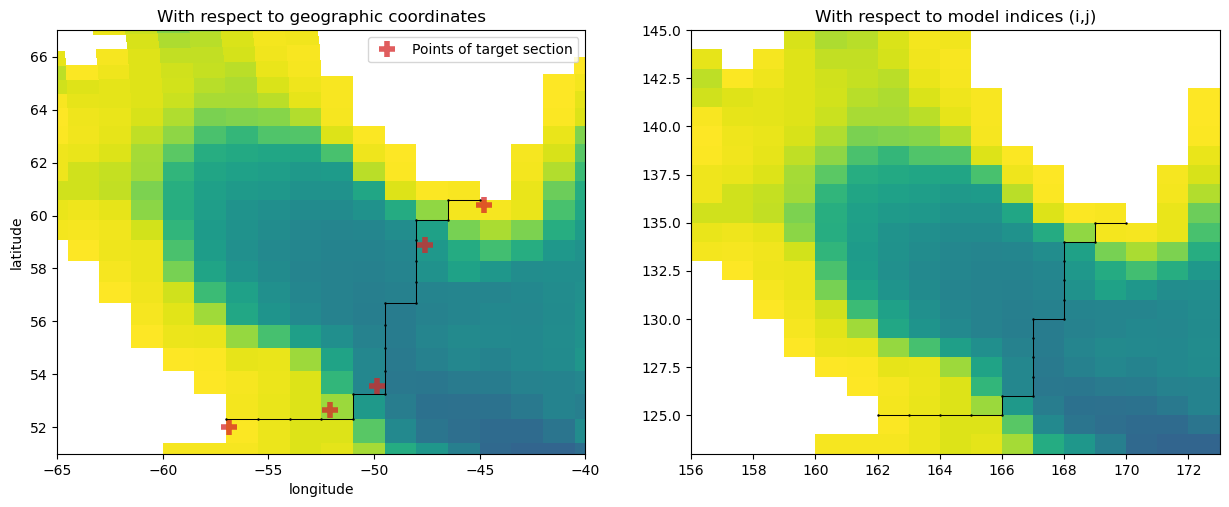

In [6]:
plt.figure(figsize=[15,5.5])
plt.subplot(1,2,1)
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), cmap="viridis_r")
plt.plot(west_section_lons, west_section_lats, "C3+", markersize=12., mew=4., alpha=0.75, label="Points of target section")
plt.plot(xwest, ywest, 'k.-', markersize=1.5, lw=0.75)
plt.axis([-65,-40, 51, 67])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("With respect to geographic coordinates")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.pcolormesh(ds['deptho'].where(ds['deptho']!=0).values, cmap="viridis_r")
plt.plot(iwest, jwest, 'k.-', markersize=1.5, lw=0.75)
plt.axis([156, 173, 123, 145])
plt.title("With respect to model indices (i,j)")
plt.show()

### Plot cell-integrated mass transport across the section

In [7]:
Trp_west = sectionate.convergent_transport(grid, iwest, jwest, layer="sigma2_l", interface="sigma2_i")

/work5/hfd/codedev/sectionate/sectionate/transports.py:393: UserWarning: The orientation of open sections is ambiguous–verify that it matches expectations!
  warnings.warn("The orientation of open sections is ambiguous–verify that it matches expectations!")


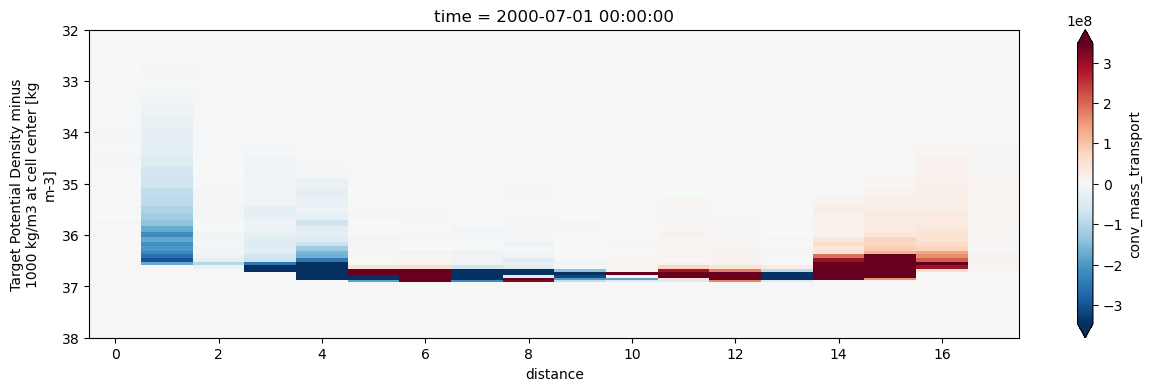

In [8]:
plt.figure(figsize=(15, 4))
Trp_west.isel(time=0)['conv_mass_transport'].swap_dims({'sect':'distance'}).plot(cmap='RdBu_r', x="distance", yincrease=False, ylim=[38,32], robust=True);

### Visualizing the normal vectors to understand the orientation of the cross-section transports

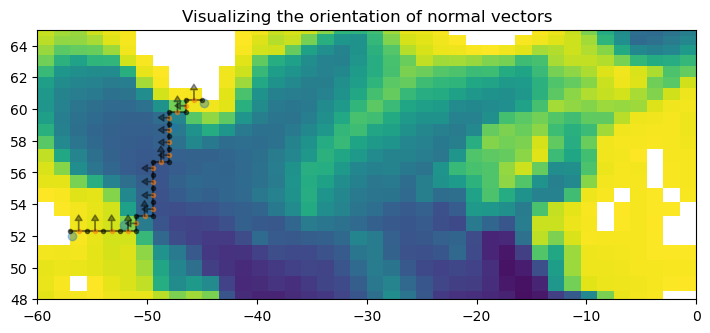

In [9]:
plt.figure(figsize=(8.5, 3.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(west_section_lons, west_section_lats, "C0o", alpha=0.4)
for (p, (var, lon, lat, sign)) in enumerate(zip(
    Trp_west.dir.values,
    Trp_west.lon.values,
    Trp_west.lat.values,
    Trp_west.sign.values
    )):
    if var=="V":
        efact = 0.
        nfact = sign 
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+float(efact), lat+float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(xwest, ywest, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp_west.lon, Trp_west.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)");
plt.title("Visualizing the orientation of normal vectors")
plt.axis([-60, 0, 48, 65]);

### Reverse the sign of the transport so that the AMOC's deep southward transport is positive

In [10]:
Trp_west = -Trp_west

## East section

In [11]:
ieast, jeast, xeast, yeast = sectionate.grid_section(
    grid,
    east_section_lons,
    east_section_lats,
    topology="MOM-tripolar"
)

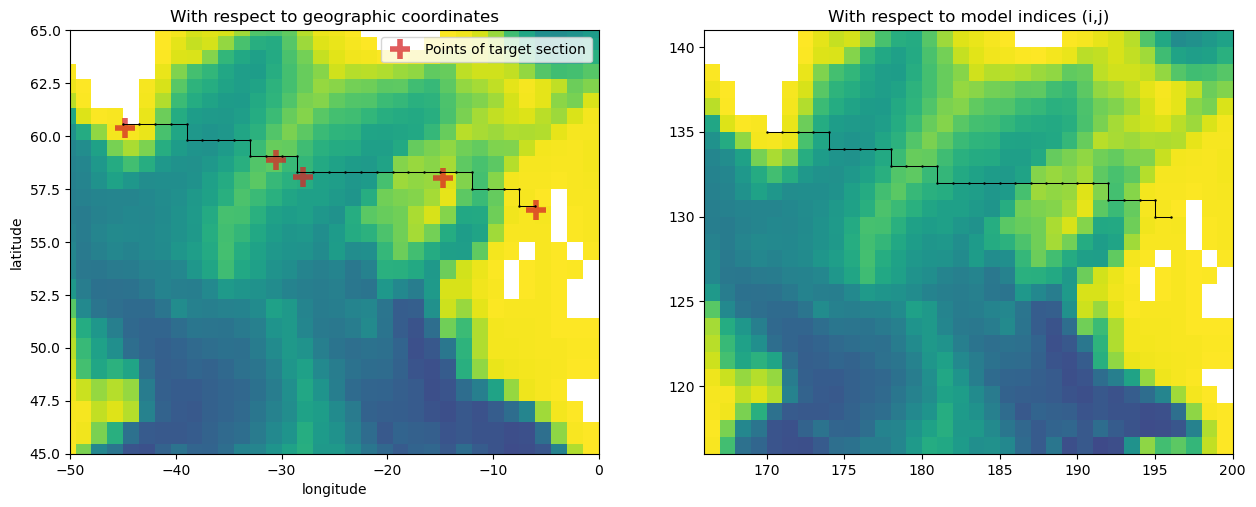

In [12]:
plt.figure(figsize=[15,5.5])
plt.subplot(1,2,1)
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), cmap="viridis_r")
plt.plot(east_section_lons, east_section_lats, "C3+", markersize=15., mew=4., alpha=0.75, label="Points of target section")
plt.plot(xeast, yeast, 'k.-', markersize=1.5, lw=0.75)
plt.axis([-50, 0, 45, 65])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("With respect to geographic coordinates")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.pcolormesh(ds['deptho'].where(ds['deptho']!=0), cmap="viridis_r")
plt.plot(ieast, jeast, 'k.-', markersize=1.5, lw=0.75)
plt.axis([166, 200, 116, 141])
plt.title("With respect to model indices (i,j)")
plt.show()

### Plot the cell-integrated mass transport across the section

In [13]:
Trp_east = sectionate.convergent_transport(grid, ieast, jeast, layer="sigma2_l", interface="sigma2_i")

/work5/hfd/codedev/sectionate/sectionate/transports.py:393: UserWarning: The orientation of open sections is ambiguous–verify that it matches expectations!
  warnings.warn("The orientation of open sections is ambiguous–verify that it matches expectations!")


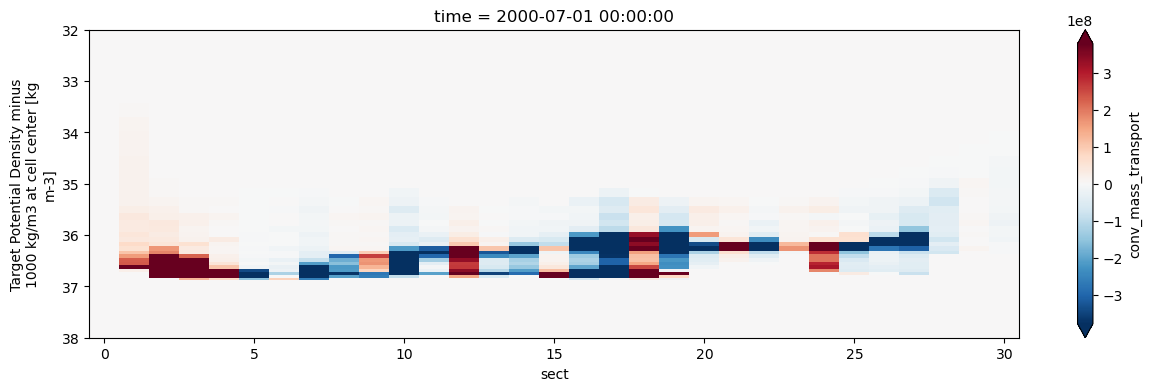

In [14]:
plt.figure(figsize=(15, 4))
Trp_east.isel(time=0)['conv_mass_transport'].plot(cmap='RdBu_r', x="sect", yincrease=False, ylim=[38,32], robust=True);

### Visualizing the normal vectors to understand the orientation of the cross-section transports

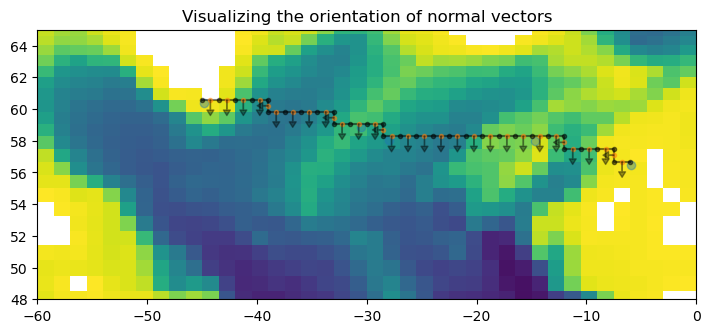

In [15]:
plt.figure(figsize=(8.5, 3.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(east_section_lons, east_section_lats, "C0o", alpha=0.4)
for (p, (var, lon, lat, sign)) in enumerate(zip(
    Trp_east.dir.values,
    Trp_east.lon.values,
    Trp_east.lat.values,
    Trp_east.sign.values
    )):
    if var=="V":
        efact = 0.
        nfact = sign 
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+float(efact), lat+float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(xeast, yeast, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp_east.lon, Trp_east.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)");
plt.title("Visualizing the orientation of normal vectors")
plt.axis([-60, 0, 48, 65]);

## Both sections together

In [16]:
i, j, x, y = sectionate.grid_section(
    grid,
    total_section_lons,
    total_section_lats,
    topology="MOM-tripolar"
)

In [17]:
Trp = sectionate.convergent_transport(grid, i, j, layer="sigma2_l", interface="sigma2_i")

/work5/hfd/codedev/sectionate/sectionate/transports.py:393: UserWarning: The orientation of open sections is ambiguous–verify that it matches expectations!
  warnings.warn("The orientation of open sections is ambiguous–verify that it matches expectations!")


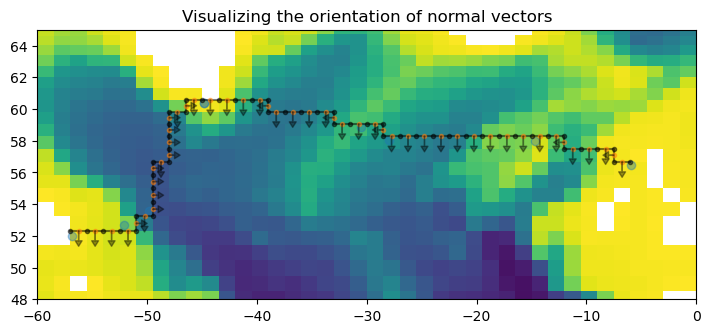

In [18]:
plt.figure(figsize=(8.5, 3.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(total_section_lons, total_section_lats, "C0o", alpha=0.4)
for (p, (var, lon, lat, sign)) in enumerate(zip(
    Trp.dir.values,
    Trp.lon.values,
    Trp.lat.values,
    Trp.sign.values
    )):
    if var=="V":
        efact = 0.
        nfact = sign 
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+float(efact), lat+float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(x, y, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp.lon, Trp.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)");
plt.title("Visualizing the orientation of normal vectors")
plt.axis([-60, 0, 48, 65]);

## Diagnosing overturning streamfunctions in depth and density space

In [19]:
import xoverturning

/work/hfd/.conda/envs/test_env_sectionate/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [20]:
names_sigma2 = {'x_center': 'sect',
              'layer': 'sigma2_l',
              'interface': 'sigma2_i'}

In [21]:
ovt_rho2_west = xoverturning.compfunc.compute_streamfunction(Trp_west, names_sigma2, transport='conv_mass_transport', fromtop=True)
ovt_rho2_east = xoverturning.compfunc.compute_streamfunction(Trp_east, names_sigma2, transport='conv_mass_transport', fromtop=True)
ovt_rho2 = xoverturning.compfunc.compute_streamfunction(Trp, names_sigma2, transport='conv_mass_transport', fromtop=True)

### OSNAP Total Residual Transport

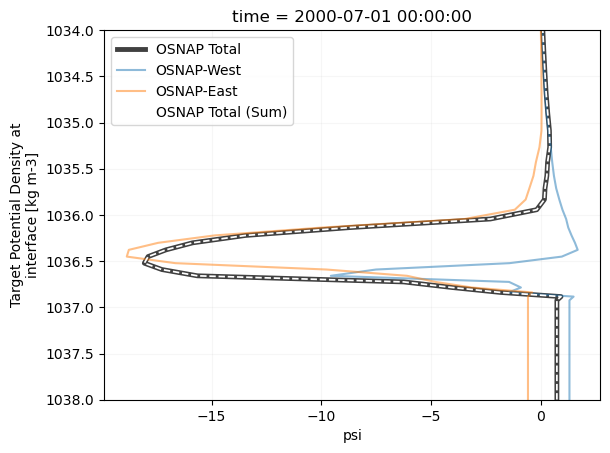

In [22]:
(ovt_rho2).isel(time=0).plot(y='rho2_i', yincrease=False, ylim=[1038,1034], label="OSNAP Total", color="k", lw=3.5, alpha=0.75)
ovt_rho2_west.isel(time=0).plot(y='rho2_i', yincrease=False, ylim=[1038,1034], label="OSNAP-West", alpha=0.5, ls="-")
ovt_rho2_east.isel(time=0).plot(y='rho2_i', yincrease=False, ylim=[1038,1034], label="OSNAP-East", alpha=0.5, ls="-")
(ovt_rho2_east + ovt_rho2_west).isel(time=0).plot(y='rho2_i', yincrease=False, ylim=[1038,1034], label="OSNAP Total (Sum)", color="white", ls="--", lw=1.25)
plt.legend();
plt.grid(True, alpha=0.1)